# 02. Step 1: Aspect & Opinion Co-Extraction (BERT-CRF & Implicit Detection)

**Aspect-Category-Opinion-Sentiment (ACOS) Quadruple Extraction**

This notebook trains and evaluates **Step 1** of the ACOS framework:
- **Model Architecture (`BertForQuadABSA`):** Pretrained BERT backbone coupled with a Linear projection layer and a Conditional Random Field (CRF) sequence tagger for extracting explicit aspect and opinion spans (`B-A`, `I-A`, `B-O`, `I-O`, `O`), plus auxiliary multi-label classification heads on the `[CLS]` token for detecting implicit aspects and opinions (`[-1, -1]`).
- **Model Checkpointing:** Saves the best fine-tuned model weights (`pytorch_model.bin`), configuration (`config.json`), and vocabulary (`vocab.txt`) to `checkpoints/step1_best/`.
- **Output Artifacts:** Produces `pred4pipeline.txt` (input bridge for Step 2), training loss/F1 curves (`plots/`), and structured CSV metrics tables (`csv/`).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Environment & Module Imports

In [3]:
!pip install -q pytorch-crf transformers huggingface_hub seaborn scikit-learn matplotlib pandas boto3
import os
import sys
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm, trange

# 1. Deteksi dinamis root direktori proyek (Colab Google Drive vs Ephemeral vs Lokal)
HAS_DRIVE = os.path.exists("/content/drive/MyDrive")

if HAS_DRIVE:
    base_project_dir = "/content/drive/MyDrive/ACOS"
    os.makedirs(base_project_dir, exist_ok=True)
    print(f"💾 Mode Google Drive Aktif: {base_project_dir}")
elif os.path.exists("/content/drive/MyDrive/ACOS/Extract-Classify-ACOS"):
    base_project_dir = "/content/drive/MyDrive/ACOS"
elif os.path.exists("Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath(".")
    print(f"💾 Mode Lokal Aktif (Current Dir): {base_project_dir}")
elif os.path.exists("../Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("..")
    print(f"💾 Mode Lokal Aktif (Parent Dir): {base_project_dir}")
elif os.path.exists("ACOS/Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("ACOS")
    print(f"💾 Mode Subfolder Aktif: {base_project_dir}")
elif os.path.exists("/content/Extract-Classify-ACOS"):
    base_project_dir = "/content"
    print(f"💾 Mode Colab Ephemeral Aktif: {base_project_dir}")
else:
    base_project_dir = os.path.abspath(".")

# 2. Sinkronisasi repositori ACOS jika folder inti belum tersedia
extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
if not os.path.exists(extract_dir):
    print(f"📥 Repositori belum ditemukan. Menyiapkan ACOS di {base_project_dir}...")
    if HAS_DRIVE:
        if os.path.exists("ACOS/Extract-Classify-ACOS"):
            import shutil
            shutil.copytree("ACOS", base_project_dir, dirs_exist_ok=True)
            print("✅ Berhasil menyalin repositori lokal ke Google Drive.")
        elif os.path.exists("/content/ACOS/Extract-Classify-ACOS"):
            import shutil
            shutil.copytree("/content/ACOS", base_project_dir, dirs_exist_ok=True)
            print("✅ Berhasil menyalin repositori ephemeral ke Google Drive.")
        else:
            !git clone https://github.com/haisyamalawwab/ACOS.git /tmp/ACOS_clone
            !cp -r /tmp/ACOS_clone/* "{base_project_dir}/"
            !rm -rf /tmp/ACOS_clone
            print("✅ Repositori berhasil dikloning ke Google Drive.")
    else:
        if not os.path.exists("Extract-Classify-ACOS") and not os.path.exists("ACOS"):
            !git clone https://github.com/haisyamalawwab/ACOS.git

notebooks_dir = os.path.join(base_project_dir, "notebooks")

for p in [base_project_dir, extract_dir, notebooks_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from modeling import BertForQuadABSA
from bert_utils.tokenization import BertTokenizer
from bert_utils.optimization import BertAdam
from run_classifier_dataset_utils import processors, output_modes, convert_examples_to_features
from eval_metrics import pred_eval

# 3. Import colab_utils with fallback download
try:
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )
except ModuleNotFoundError:
    import urllib.request
    print("⚠️ Downloading colab_utils.py fallback directly from GitHub...")
    raw_url = "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/notebooks/colab_utils.py"
    urllib.request.urlretrieve(raw_url, "colab_utils.py")
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Active PyTorch Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU Model: {torch.cuda.get_device_name(0)}")
print(f"📂 Base project directory: {base_project_dir}")
print(f"📁 Extract & Model directory: {extract_dir}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 97.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 9.9 MB/s eta 0:00:00
📥 Cloning ACOS repository from GitHub into Colab environment...
Cloning into 'ACOS'...
remote: Enumerating objects: 991, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 991 (delta 97), reused 82 (delta 58), pack-reused 841 (from 2)
Receiving objects: 100% (991/991), 8.91 MiB | 22.64 MiB/s, done.
Resolving deltas: 100% (542/542), done.
⚡ Active PyTorch Device: cuda
   GPU Model: Tesla T4
📂 Base project directory: /content/drive/MyDrive/ACOS
📁 Extract & Model directory: /content/drive/MyDrive/ACOS/Extract-Classify-ACOS


## 2. Configuration & Hyperparameters
Select domain (`rest16` or `laptop`), batch size, epochs, and initialize the timestamped output directory.

In [4]:
# Pipeline Configuration
DOMAIN = "rest16"              # 'rest16' (Restaurant-ACOS) or 'laptop' (Laptop-ACOS)
TASK_NAME = "quad"
MODEL_TYPE = "quad"
DO_TRAIN = True                # Set to False to skip training and evaluate saved checkpoint
DO_EVAL = True
MAX_SEQ_LENGTH = 128
TRAIN_BATCH_SIZE = 24
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
NUM_TRAIN_EPOCHS = 15          # Default is 30, 15 is great for fast Colab training
WARMUP_PROPORTION = 0.1
SEED = 42

# Set random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Pretrained BERT Directory
bert_model_dir = os.path.join(base_project_dir, "bert_base_uncased")
download_bert_pretrained(target_dir=bert_model_dir)

# Data directory
data_dir = extract_dir

# Initialize timestamped output session directory
results_base = os.path.join(base_project_dir, "results")
session_dirs = setup_timestamped_run_dir(base_dir=results_base, domain=DOMAIN)
step1_checkpoint_dir = session_dirs["step1_checkpoint"]

print(f"📁 Step 1 Checkpoint will be saved to: {step1_checkpoint_dir}")
plots_dir = session_dirs["plots"]
csv_dir = session_dirs["csv"]
md_dir = session_dirs["md"]
logs_dir = session_dirs["logs"]

rep = MarkdownReport(
    f"02 - Step 1: Ekstraksi Aspect & Opinion [{DOMAIN.upper()}]",
    md_dir,
    filename="02_step1_ekstraksi.md",
    meta={
        "domain": DOMAIN, "epochs": NUM_TRAIN_EPOCHS,
        "batch_train": TRAIN_BATCH_SIZE, "lr": LEARNING_RATE,
        "max_seq_length": MAX_SEQ_LENGTH, "seed": SEED, "device": str(device),
        "session_dir": session_dirs["root"],
    },
)

df_cfg = pd.DataFrame([
    {"Parameter": "domain", "Nilai": DOMAIN},
    {"Parameter": "num_train_epochs", "Nilai": NUM_TRAIN_EPOCHS},
    {"Parameter": "train_batch_size", "Nilai": TRAIN_BATCH_SIZE},
    {"Parameter": "eval_batch_size", "Nilai": EVAL_BATCH_SIZE},
    {"Parameter": "learning_rate", "Nilai": LEARNING_RATE},
    {"Parameter": "max_seq_length", "Nilai": MAX_SEQ_LENGTH},
    {"Parameter": "warmup_proportion", "Nilai": WARMUP_PROPORTION},
    {"Parameter": "seed", "Nilai": SEED},
    {"Parameter": "device", "Nilai": str(device)},
])
rep.section("1. Konfigurasi")
export_step_table(df_cfg, name="step1_00_konfigurasi", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Konfigurasi Step 1 ({DOMAIN.upper()})")
rep.table(df_cfg, caption="Hyperparameter yang dipakai")


📥 Downloading config.json to /content/drive/MyDrive/ACOS/bert_base_uncased/config.json ...
📥 Downloading pytorch_model.bin to /content/drive/MyDrive/ACOS/bert_base_uncased/pytorch_model.bin ...
📥 Downloading vocab.txt to /content/drive/MyDrive/ACOS/bert_base_uncased/vocab.txt ...
📁 Initialized timestamped session directory: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800
📁 Step 1 Checkpoint will be saved to: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/checkpoints/step1_best
=== Konfigurasi Step 1 (REST16) (9 baris) ===


,Parameter,Nilai
0,domain,rest16
1,num_train_epochs,15
2,train_batch_size,24
3,eval_batch_size,16
4,learning_rate,0.00002
5,max_seq_length,128
6,warmup_proportion,0.1
7,seed,42
8,device,cuda


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/csv/step1_00_konfigurasi.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/step1_00_konfigurasi.md


## 3. Data Loading & Feature Conversion
Load train, dev, and test examples and convert them into PyTorch TensorDatasets.

Tag sekuens (6): ['[CLS]', 'O', 'I-A', 'B-A', 'I-O', 'B-O']
Sampel gold test dimuat: 583
=== Ringkasan Fitur Test Step 1 (REST16) (1 baris) ===


,Split,Jumlah_Sampel,Token_Min,Token_Median,Token_Maks,Kalimat_Implicit_Aspect,Kalimat_Implicit_Opinion
0,test (eval),583,3,16.0,93,197,164


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/csv/step1_01_ringkasan_fitur.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/step1_01_ringkasan_fitur.md
=== Distribusi Tag Sekuens Gold Test (REST16) (5 baris) ===


,Tag,Jumlah_Token,Persen
0,O,72584,97.266
1,B-O,648,0.868
2,B-A,608,0.815
3,I-A,524,0.702
4,I-O,260,0.348


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/csv/step1_02_distribusi_tag_gold.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/step1_02_distribusi_tag_gold.md


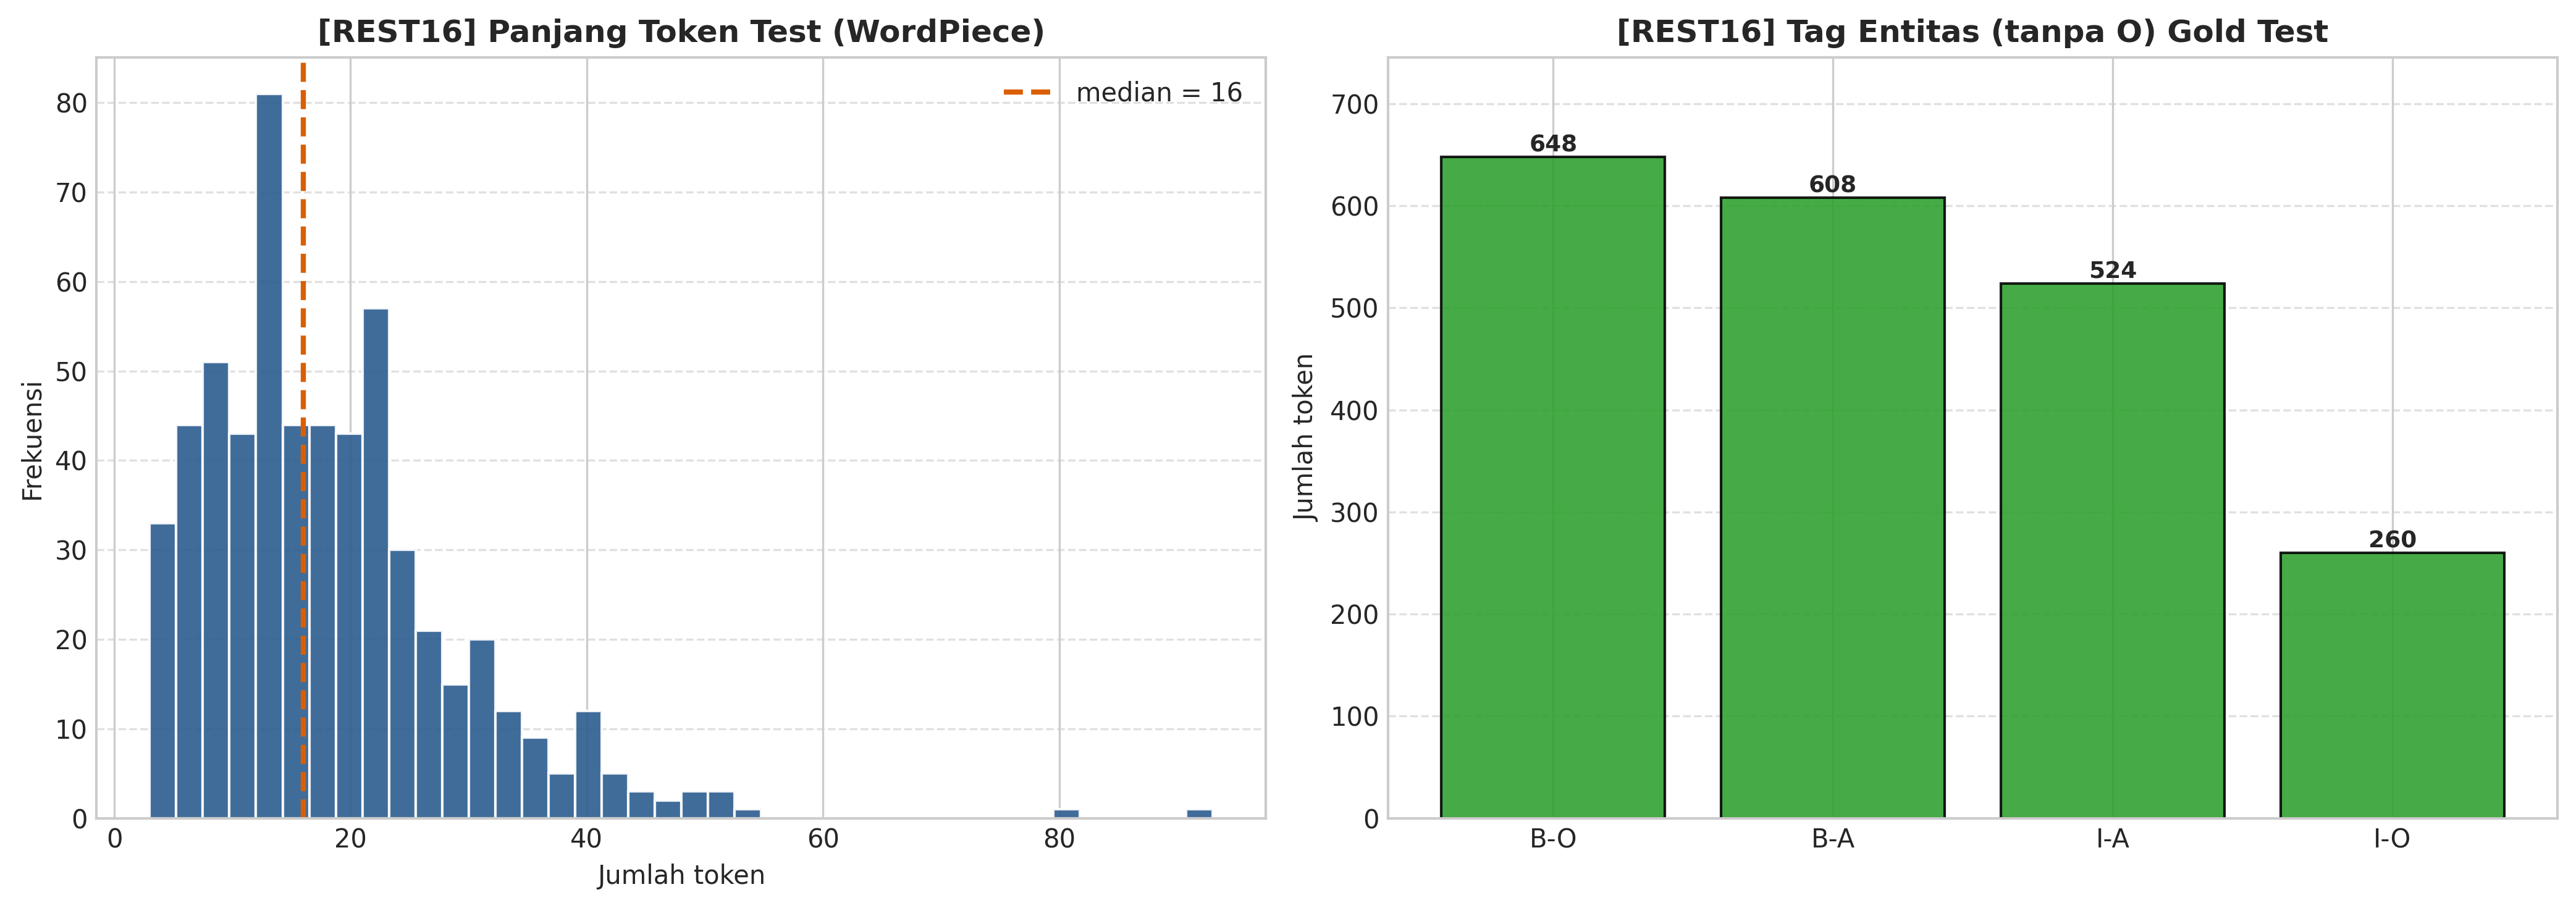

In [5]:
tokenizer = BertTokenizer.from_pretrained(bert_model_dir, do_lower_case=True)
processor = processors[TASK_NAME]()
label_list = processor.get_labels(DOMAIN)
num_labels = len(label_list[1])
label_map_seq = {label: i for i, label in enumerate(label_list[1])}

print(f"Tag sekuens ({num_labels}): {label_list[1]}")

# features_step1 membungkus convert_examples_to_features(examples, label_list,
# max_seq_length, tokenizer, output_mode, task_name). Signature aslinya tidak
# menerima kwarg domain_type, sehingga wrapper dipakai agar pemanggilan valid.
eval_examples = processor.get_dev_examples(data_dir, DOMAIN)
eval_features = features_step1(eval_examples, label_list, MAX_SEQ_LENGTH, tokenizer,
                               output_modes[TASK_NAME], TASK_NAME)

all_input_ids = torch.tensor([f.aspect_input_ids for f in eval_features], dtype=torch.long)
all_input_mask = torch.tensor([f.aspect_input_mask for f in eval_features], dtype=torch.long)
all_segment_ids = torch.tensor([f.aspect_segment_ids for f in eval_features], dtype=torch.long)
all_label_ids = torch.tensor([f.aspect_ids for f in eval_features], dtype=torch.long)
all_exist_imp_aspect = torch.tensor([f.exist_imp_aspect for f in eval_features], dtype=torch.long)
all_exist_imp_opinion = torch.tensor([f.exist_imp_opinion for f in eval_features], dtype=torch.long)
all_tokens_len = torch.tensor([f.tokens_len for f in eval_features], dtype=torch.long)

eval_data = TensorDataset(all_tokens_len, all_input_ids, all_input_mask, all_label_ids,
                          all_segment_ids, all_exist_imp_aspect, all_exist_imp_opinion)
eval_dataloader = DataLoader(eval_data, sampler=SequentialSampler(eval_data), batch_size=EVAL_BATCH_SIZE)

# Gold test: bangun label sekuens B-A/I-A/B-O/I-O plus flag implicit per kalimat
eval_gold_rows = []
test_quad_file = os.path.join(data_dir, "tokenized_data", f"{DOMAIN}_test_quad_bert.tsv")
with open(test_quad_file, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip().split("\t")
        cur_text = tokenizer.convert_tokens_to_ids(line[0].split(" "))
        cur_exist_imp_aspect = 0
        cur_exist_imp_opinion = 0
        aspect_labels = [label_map_seq["O"] for _ in range(MAX_SEQ_LENGTH)]
        for quad in line[1:]:
            cur_aspect = quad.split(" ")[0]
            cur_opinion = quad.split(" ")[-1]
            a_st, a_ed = int(cur_aspect.split(",")[0]), int(cur_aspect.split(",")[1])
            if a_ed != -1:
                aspect_labels[a_st] = label_map_seq["B-A"]
                for i in range(a_st + 1, a_ed):
                    aspect_labels[i] = label_map_seq["I-A"]
            else:
                cur_exist_imp_aspect = 1
            o_st, o_ed = int(cur_opinion.split(",")[0]), int(cur_opinion.split(",")[1])
            if o_ed != -1:
                aspect_labels[o_st] = label_map_seq["B-O"]
                for i in range(o_st + 1, o_ed):
                    aspect_labels[i] = label_map_seq["I-O"]
            else:
                cur_exist_imp_opinion = 1
        eval_gold_rows.append([cur_text, [aspect_labels, cur_exist_imp_aspect, cur_exist_imp_opinion]])

input_text = [ele[0] for ele in eval_gold_rows]
pairgold = [item for ele in eval_gold_rows for item in ele[1]]
eval_gold = [input_text, pairgold]
print(f"Sampel gold test dimuat: {len(input_text)}")

# Tabel 1: ringkasan fitur test
df_feat = pd.DataFrame([{
    "Split": "test (eval)",
    "Jumlah_Sampel": len(eval_features),
    "Token_Min": int(all_tokens_len.min()),
    "Token_Median": float(all_tokens_len.median()),
    "Token_Maks": int(all_tokens_len.max()),
    "Kalimat_Implicit_Aspect": int(all_exist_imp_aspect.sum()),
    "Kalimat_Implicit_Opinion": int(all_exist_imp_opinion.sum()),
}])
rep.section("2. Data & fitur")
export_step_table(df_feat, name="step1_01_ringkasan_fitur", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Ringkasan Fitur Test Step 1 ({DOMAIN.upper()})")
rep.table(df_feat, caption="Statistik fitur test")

# Tabel 2: distribusi tag sekuens pada gold test
tag_names = {i: t for t, i in label_map_seq.items()}
tag_counts = {}
for row in eval_gold_rows:
    for v in row[1][0]:
        tag_counts[v] = tag_counts.get(v, 0) + 1
df_tags = (pd.DataFrame([{"Tag": tag_names.get(k, k), "Jumlah_Token": v}
                         for k, v in tag_counts.items()])
           .sort_values("Jumlah_Token", ascending=False).reset_index(drop=True))
tot_tok = int(df_tags["Jumlah_Token"].sum())
df_tags["Persen"] = (df_tags["Jumlah_Token"] / tot_tok * 100).round(3)
export_step_table(df_tags, name="step1_02_distribusi_tag_gold", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Distribusi Tag Sekuens Gold Test ({DOMAIN.upper()})",
                  notes="Tag `O` mendominasi karena padding sampai max_seq_length ikut dihitung.")
rep.table(df_tags, caption="Distribusi tag pada gold test")

# Plot profil data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(all_tokens_len.numpy(), bins=40, color="#2b5c8f", edgecolor="white", alpha=0.9)
_med = float(all_tokens_len.median())
axes[0].axvline(_med, color="#d95f02", linestyle="--", linewidth=2, label=f"median = {_med:.0f}")
axes[0].set_title(f"[{DOMAIN.upper()}] Panjang Token Test (WordPiece)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Jumlah token")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

df_nonO = df_tags[df_tags["Tag"] != "O"]
axes[1].bar(df_nonO["Tag"], df_nonO["Jumlah_Token"], color="#2ca02c", edgecolor="black", alpha=0.88)
for x, v in zip(df_nonO["Tag"], df_nonO["Jumlah_Token"]):
    axes[1].text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title(f"[{DOMAIN.upper()}] Tag Entitas (tanpa O) Gold Test", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Jumlah token")
axes[1].margins(y=0.15)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
p_data = os.path.join(plots_dir, "02a_step1_data_profile.png")
plt.savefig(p_data, dpi=300)
plt.show()
plt.close()
rep.image(p_data, "Profil data step 1: panjang token dan distribusi tag entitas")


## 4. Model Initialization: `BertForQuadABSA`
Instantiate BERT + Linear + CRF sequence tagger model.

In [6]:
model = BertForQuadABSA.from_pretrained(bert_model_dir, num_labels=num_labels)
model.to(device)
print(f"✅ Initialized BertForQuadABSA model ({sum(p.numel() for p in model.parameters()):,} parameters).")

✅ Initialized BertForQuadABSA model (110,080,570 parameters).


## 5. Training Loop with Model Checkpoint Persistence
Performs fine-tuning with Adam optimizer and linear learning rate warmup. Evaluates validation Micro-F1 after every epoch and saves the best model checkpoint to `checkpoints/step1_best/`.

In [7]:
if DO_TRAIN:
    train_examples = processor.get_train_examples(data_dir, DOMAIN)
    train_features = features_step1(train_examples, label_list, MAX_SEQ_LENGTH, tokenizer,
                                    output_modes[TASK_NAME], TASK_NAME)

    tr_input_ids = torch.tensor([f.aspect_input_ids for f in train_features], dtype=torch.long)
    tr_input_mask = torch.tensor([f.aspect_input_mask for f in train_features], dtype=torch.long)
    tr_segment_ids = torch.tensor([f.aspect_segment_ids for f in train_features], dtype=torch.long)
    tr_label_ids = torch.tensor([f.aspect_ids for f in train_features], dtype=torch.long)
    tr_exist_imp_aspect = torch.tensor([f.exist_imp_aspect for f in train_features], dtype=torch.long)
    tr_exist_imp_opinion = torch.tensor([f.exist_imp_opinion for f in train_features], dtype=torch.long)
    tr_tokens_len = torch.tensor([f.tokens_len for f in train_features], dtype=torch.long)

    train_data = TensorDataset(tr_tokens_len, tr_input_ids, tr_input_mask, tr_label_ids,
                               tr_segment_ids, tr_exist_imp_aspect, tr_exist_imp_opinion)
    train_dataloader = DataLoader(train_data, sampler=RandomSampler(train_data),
                                 batch_size=TRAIN_BATCH_SIZE)

    num_train_optimization_steps = len(train_dataloader) * NUM_TRAIN_EPOCHS

    param_optimizer = list(model.named_parameters())
    no_decay = ["bias", "LayerNorm.bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {"params": [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)], "weight_decay": 0.01},
        {"params": [p for n, p in param_optimizer if any(nd in n for nd in no_decay)], "weight_decay": 0.0},
    ]
    optimizer = BertAdam(optimizer_grouped_parameters, lr=LEARNING_RATE,
                         warmup=WARMUP_PROPORTION, t_total=num_train_optimization_steps)

    print(f"Mulai training step 1: {NUM_TRAIN_EPOCHS} epoch, {len(train_dataloader)} step/epoch")

    class ArgsHelper:
        def __init__(self):
            self.output_dir = logs_dir
            self.max_seq_length = MAX_SEQ_LENGTH

    eval_args = ArgsHelper()

    import logging
    logger = logging.getLogger("Step1")

    best_val_f1 = 0.0
    training_history = []
    step_loss_log = []

    for epoch in range(1, NUM_TRAIN_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for step, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch}/{NUM_TRAIN_EPOCHS}")):
            batch = tuple(t.to(device) for t in batch)
            _len, _ids, _mask, _labels, _seg_ids, _imp_a, _imp_o = batch

            # BertForQuadABSA mengembalikan ([total_loss], [pred_tags, imp_a, imp_o]).
            # unpack_model_output mengambil skalar loss agar .backward() tidak
            # dipanggil pada objek list.
            out = model(
                aspect_input_ids=_ids,
                aspect_labels=_labels,
                aspect_token_type_ids=_seg_ids,
                aspect_attention_mask=_mask,
                exist_imp_aspect=_imp_a,
                exist_imp_opinion=_imp_o,
            )
            loss, _ = unpack_model_output(out)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()
            step_loss_log.append({"epoch": epoch, "step": step + 1, "loss": loss.item()})

        avg_loss = total_loss / len(train_dataloader)

        model.eval()
        val_res = pred_eval(epoch, eval_args, logger, tokenizer, model, eval_dataloader,
                            eval_gold, label_list, device, TASK_NAME, eval_type="test")

        val_p = val_res.get("precision", 0.0)
        val_r = val_res.get("recall", 0.0)
        val_f1 = val_res.get("micro-F1", 0.0)

        print(f"Epoch {epoch:02d} | loss {avg_loss:.4f} | P {val_p*100:.2f}% | "
              f"R {val_r*100:.2f}% | micro-F1 {val_f1*100:.2f}%")

        training_history.append({
            "epoch": epoch, "loss": avg_loss,
            "precision": val_p, "recall": val_r, "micro-F1": val_f1,
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            print(f"  -> micro-F1 terbaik baru ({best_val_f1*100:.2f}%), menyimpan checkpoint")
            torch.save(model.state_dict(), os.path.join(step1_checkpoint_dir, "pytorch_model.bin"))
            model.config.to_json_file(os.path.join(step1_checkpoint_dir, "config.json"))
            tokenizer.save_vocabulary(step1_checkpoint_dir)
            with open(os.path.join(step1_checkpoint_dir, "checkpoint_metadata.json"), "w") as mf:
                json.dump({
                    "epoch": epoch, "best_micro_f1": best_val_f1,
                    "precision": val_p, "recall": val_r,
                    "domain": DOMAIN, "task": "Step1_Aspect_Opinion_Extraction",
                }, mf, indent=2)

    # Kurva training + CSV riwayat
    plot_history_path = os.path.join(plots_dir, "03_step1_training_loss_f1_curve.png")
    csv_history_path = os.path.join(csv_dir, "step1_training_history.csv")
    plot_training_history(training_history, task_name="Step 1 (BERT-CRF)",
                          output_plot_path=plot_history_path, output_csv_path=csv_history_path)

    df_hist = pd.DataFrame(training_history)
    df_hist_pct = df_hist.copy()
    for c in ["precision", "recall", "micro-F1"]:
        df_hist_pct[c] = (df_hist_pct[c] * 100).round(2)

    rep.section("3. Riwayat training per epoch")
    export_step_table(df_hist_pct, name="step1_03_riwayat_epoch", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Riwayat Training Step 1 per Epoch ({DOMAIN.upper()})",
                      notes="Precision/Recall/micro-F1 dalam persen, dihitung pada test set.",
                      max_rows_md=NUM_TRAIN_EPOCHS)
    rep.table(df_hist_pct, max_rows=NUM_TRAIN_EPOCHS, caption="Metrik per epoch")

    # Loss per step
    df_steps = pd.DataFrame(step_loss_log)
    export_step_table(df_steps.groupby("epoch")["loss"].describe().reset_index(),
                      name="step1_04_statistik_loss_per_epoch", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Statistik Loss per Epoch ({DOMAIN.upper()})",
                      max_rows_md=NUM_TRAIN_EPOCHS)
    df_steps.to_csv(os.path.join(csv_dir, "step1_loss_per_step.csv"), index=False, encoding="utf-8")

    # Baris terbaik
    best_row = df_hist_pct.loc[df_hist_pct["micro-F1"].idxmax()]
    rep.section("4. Epoch terbaik").kv({
        "epoch": int(best_row["epoch"]),
        "loss": f"{best_row['loss']:.4f}",
        "precision": f"{best_row['precision']:.2f}%",
        "recall": f"{best_row['recall']:.2f}%",
        "micro-F1": f"{best_row['micro-F1']:.2f}%",
        "checkpoint": step1_checkpoint_dir,
    })
    print(f"Epoch terbaik: {int(best_row['epoch'])} (micro-F1 {best_row['micro-F1']:.2f}%)")
else:
    print("DO_TRAIN=False, training dilewati. Lanjut ke pemuatan checkpoint.")
    training_history = []


Mulai training step 1: 15 epoch, 64 step/epoch


Epoch 1/15:   0%|          | 0/64 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torchcrf/__init__.py:249: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:614.)
  score = torch.where(mask[i].unsqueeze(1), next_score, score)
/content/drive/MyDrive/ACOS/Extract-Classify-ACOS/bert_utils/optimization.py:275: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1853.)
  next_m.mul_(beta1).add_(1 - beta1, grad)
Epoch 1/15: 100%|██████████| 64/64 [00:48<00:00,  1.31it/s]


tp: 885.0. fp: 983.0. fn: 730.0.
Epoch 01 | loss 15.9915 | P 47.38% | R 54.80% | micro-F1 50.82%
  -> micro-F1 terbaik baru (50.82%), menyimpan checkpoint


Epoch 2/15: 100%|██████████| 64/64 [00:49<00:00,  1.29it/s]


tp: 1225.0. fp: 367.0. fn: 390.0.
Epoch 02 | loss 5.0520 | P 76.95% | R 75.85% | micro-F1 76.40%
  -> micro-F1 terbaik baru (76.40%), menyimpan checkpoint


...

tp: 1341.0. fp: 367.0. fn: 274.0.
Epoch 15 | loss 0.0900 | P 78.51% | R 83.03% | micro-F1 80.71%
📈 Saved training plot: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/plots/03_step1_training_loss_f1_curve.png
=== Riwayat Training Step 1 per Epoch (REST16) (15 baris) ===


,epoch,loss,precision,recall,micro-F1
0,1,15.991531,47.38,54.80,50.82
1,2,5.052014,76.95,75.85,76.40
2,3,2.732241,76.00,81.98,78.88
3,4,1.625833,79.01,82.04,80.50
4,5,1.079806,81.46,79.44,80.44
5,6,0.706673,81.04,81.24,81.14
6,7,0.547820,78.30,83.10,80.62
7,8,0.398491,78.16,84.64,81.27
8,9,0.300534,78.77,83.41,81.02
9,10,0.224534,77.92,82.60,80.19


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/csv/step1_03_riwayat_epoch.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/step1_03_riwayat_epoch.md
=== Statistik Loss per Epoch (REST16) (15 baris) ===


,epoch,count,mean,std,min,25%,50%,75%,max
0,1,64.0,15.991531,8.294467,6.507822,9.284439,13.400290,22.348907,43.105865
1,2,64.0,5.052014,1.189639,3.023938,4.312845,4.885475,5.628038,9.617948
2,3,64.0,2.732241,0.786414,1.425415,2.123595,2.620115,3.286645,4.725603
3,4,64.0,1.625833,0.624371,0.849977,1.207489,1.475886,1.870045,3.875962
4,5,64.0,1.079806,0.522441,0.356634,0.727698,0.936125,1.168251,2.686030
5,6,64.0,0.706673,0.465641,0.196688,0.444734,0.599899,0.778343,2.600371
6,7,64.0,0.547820,0.370065,0.144569,0.287018,0.423055,0.720021,2.344516
7,8,64.0,0.398491,0.340202,0.096571,0.173340,0.285986,0.488777,2.161892
8,9,64.0,0.300534,0.267308,0.046007,0.128847,0.196685,0.404980,1.369495
9,10,64.0,0.224534,0.209027,0.044720,0.084822,0.150906,0.265084,1.157658


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/csv/step1_04_statistik_loss_per_epoch.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/step1_04_statistik_loss_per_epoch.md
Epoch terbaik: 8 (micro-F1 81.27%)


## 6. Standalone Checkpoint Loading & Final Test Set Inference
Loads the fine-tuned model checkpoint from `checkpoints/step1_best/` and generates the pipeline prediction file `logs/pred4pipeline.txt`.

Memuat checkpoint step 1 terbaik dari: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/checkpoints/step1_best
tp: 1367.0. fp: 382.0. fn: 248.0.
=== Hasil Akhir Step 1 - Test Set (REST16) (3 baris) ===


,Metrik,Nilai,Persen
0,precision,0.781589,78.16
1,recall,0.846440,84.64
2,micro-F1,0.812723,81.27


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/csv/step1_05_hasil_test_final.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/step1_05_hasil_test_final.md

Hasil akhir step 1 pada test set:
  precision: 78.16%
  recall: 84.64%
  micro-F1: 81.27%

pred4pipeline.txt terbentuk: 582 kalimat berprediksi
=== Ringkasan Prediksi Step 1 (REST16) (1 baris) ===


,Kalimat_Berprediksi,Total_Aspect,Total_Opinion,Kalimat_Implicit_Aspect,Kalimat_Implicit_Opinion,Estimasi_Calon_Pasangan
0,582,860,886,194,165,1511


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/csv/step1_06_ringkasan_prediksi.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/step1_06_ringkasan_prediksi.md
=== Detail Prediksi per Kalimat - 30 Pertama (REST16) (30 baris) ===


,Sentence_ID,Teks,N_Aspect,N_Opinion,Ada_Implicit_Aspect,Ada_Implicit_Opinion,Calon_Pasangan
0,0,##m !,1,2,True,True,2
1,1,really good su ##shi .,1,1,False,False,1
2,2,the biggest portions but adequate .,1,2,False,False,2
3,3,tea cr ##eme br ##ule ##e is a must !,1,1,False,False,1
4,4,has great su ##shi and even better service .,2,2,False,False,4
5,5,entire staff was extremely acc ##omo ##dating ...,1,1,False,False,1
6,6,' ve been to this restaurant over a dozen time...,1,0,False,False,1
7,7,owner is bell ##iger ##ent to guests that have...,1,1,False,False,1
8,8,food !,1,1,False,False,1
9,9,is a great place to get a delicious meal .,2,2,False,False,4


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/csv/step1_07_detail_prediksi_per_kalimat.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/step1_07_detail_prediksi_per_kalimat.md


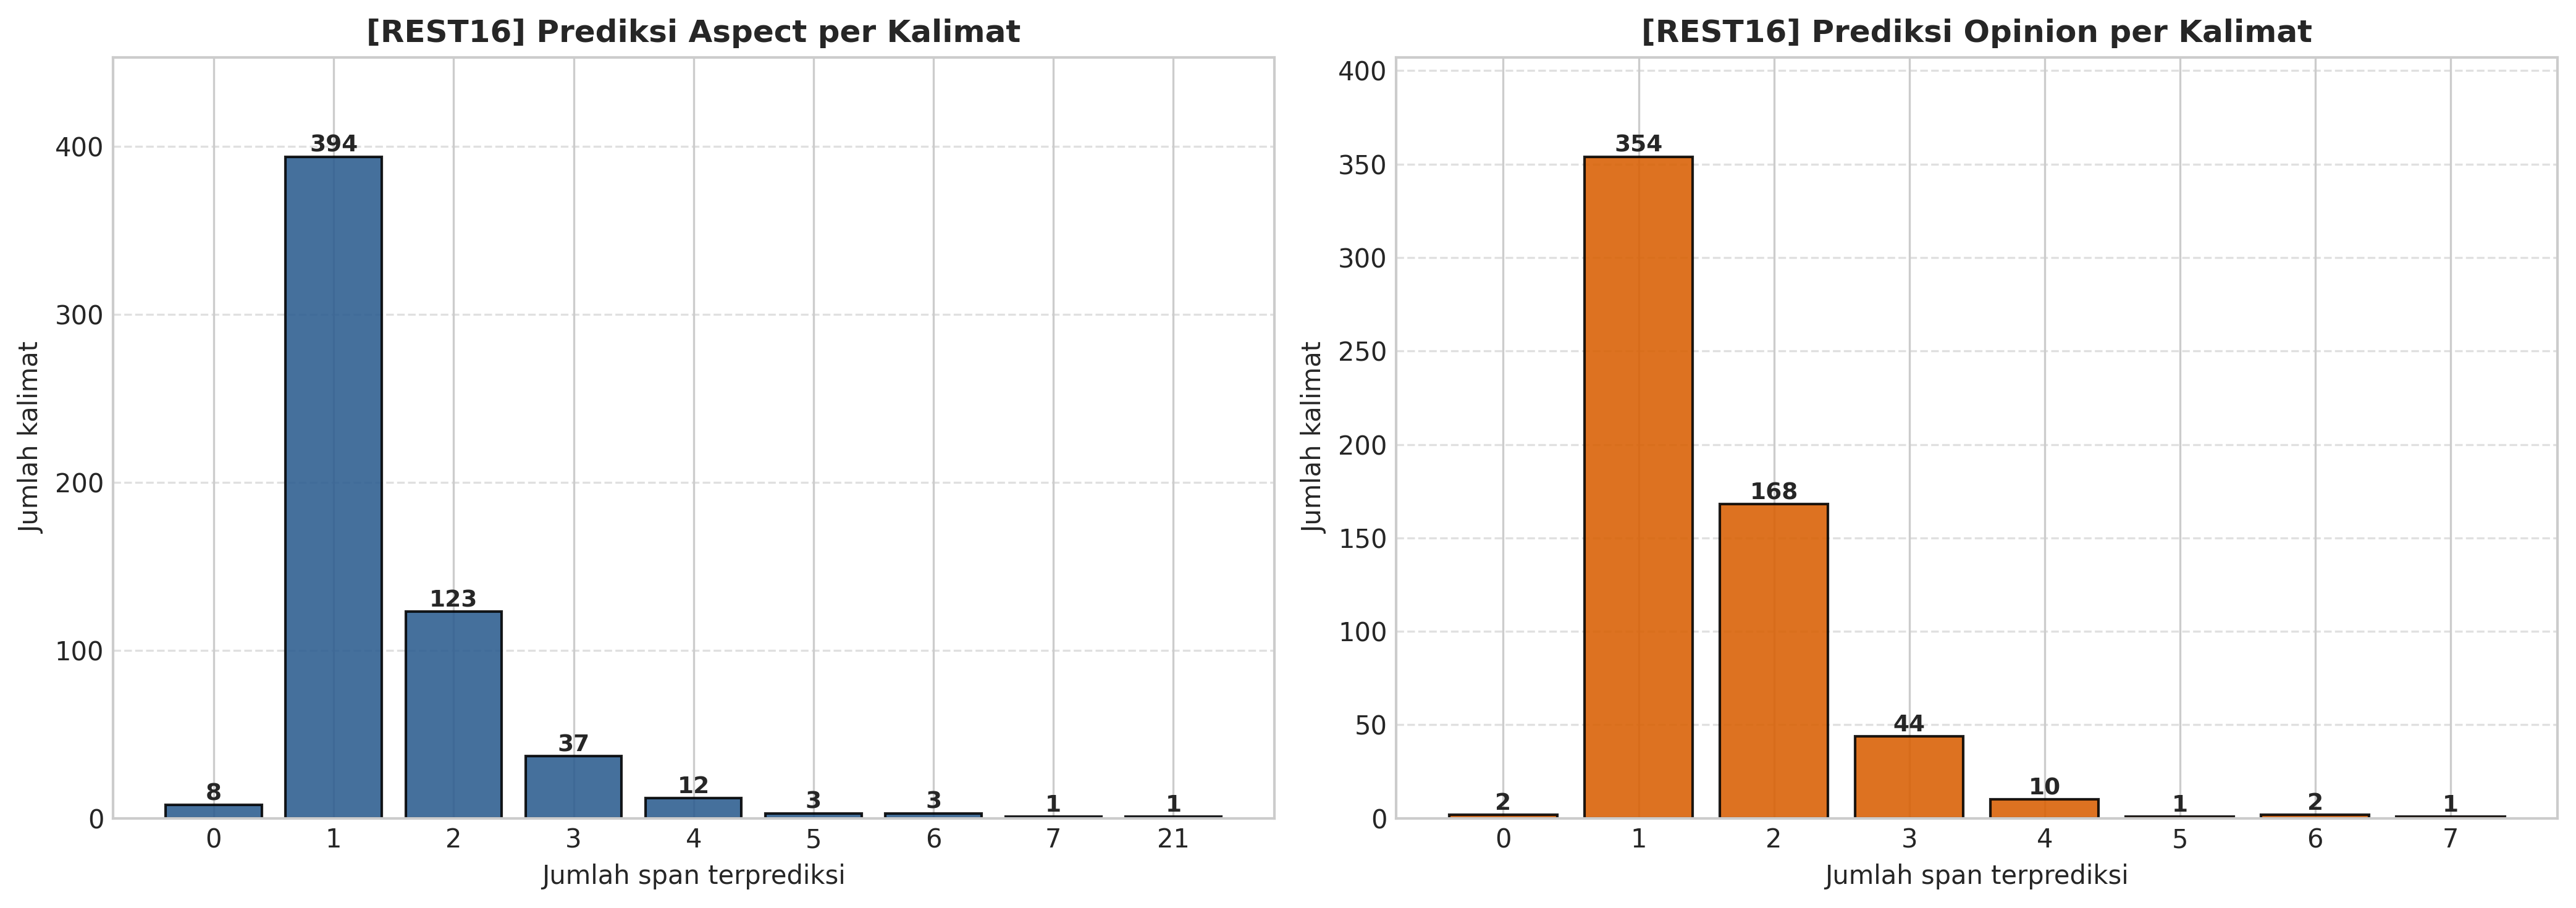

Contoh 3 baris pertama pred4pipeline.txt:
  ##m !	a--1,-1	o-0,1	o--1,-1
  really good su ##shi .	a-3,5	o-2,3
  the biggest portions but adequate .	a-3,4	o-0,3	o-5,6


In [8]:
print(f"Memuat checkpoint step 1 terbaik dari: {step1_checkpoint_dir}")
model = BertForQuadABSA.from_pretrained(step1_checkpoint_dir, num_labels=num_labels)
model.to(device)
model.eval()

class ArgsHelper:
    def __init__(self):
        self.output_dir = logs_dir
        self.max_seq_length = MAX_SEQ_LENGTH

eval_args = ArgsHelper()

import logging
logger = logging.getLogger("Step1_Final")
final_res = pred_eval("best_checkpoint", eval_args, logger, tokenizer, model, eval_dataloader,
                      eval_gold, label_list, device, TASK_NAME, eval_type="test")

df_final = pd.DataFrame([{
    "Metrik": k,
    "Nilai": v,
    "Persen": round(v * 100, 2) if isinstance(v, float) else v,
} for k, v in final_res.items()])

rep.section("5. Hasil akhir step 1 pada test set")
export_step_table(df_final, name="step1_05_hasil_test_final", csv_dir=csv_dir, md_dir=md_dir,
                  title=f"Hasil Akhir Step 1 - Test Set ({DOMAIN.upper()})",
                  notes="Skor ini mengukur ekstraksi span aspect/opinion, bukan quadruple penuh.")
rep.table(df_final, caption="Metrik akhir step 1")

print("\nHasil akhir step 1 pada test set:")
for k, v in final_res.items():
    print(f"  {k}: {v*100:.2f}%")

# Verifikasi + profil pred4pipeline.txt yang menjadi input step 3
pred_file = os.path.join(logs_dir, "pred4pipeline.txt")
if os.path.exists(pred_file):
    with open(pred_file, "r", encoding="utf-8") as f:
        pred_lines = [ln.strip() for ln in f if ln.strip()]
    print(f"\npred4pipeline.txt terbentuk: {len(pred_lines)} kalimat berprediksi")

    prof = []
    for idx, ln in enumerate(pred_lines):
        parts = ln.split("\t")
        if len(parts) < 2:
            continue
        tags = parts[1:]
        n_a = sum(1 for t in tags if t.startswith("a-"))
        n_o = sum(1 for t in tags if t.startswith("o-"))
        prof.append({
            "Sentence_ID": idx,
            "Teks": parts[0][:70] + ("..." if len(parts[0]) > 70 else ""),
            "N_Aspect": n_a,
            "N_Opinion": n_o,
            "Ada_Implicit_Aspect": "a--1,-1" in tags,
            "Ada_Implicit_Opinion": "o--1,-1" in tags,
            "Calon_Pasangan": max(n_a, 1) * max(n_o, 1),
        })
    df_pred = pd.DataFrame(prof)

    rep.section("6. Profil prediksi step 1 (input step 3)")
    if not df_pred.empty:
        ringkas = pd.DataFrame([{
            "Kalimat_Berprediksi": len(df_pred),
            "Total_Aspect": int(df_pred["N_Aspect"].sum()),
            "Total_Opinion": int(df_pred["N_Opinion"].sum()),
            "Kalimat_Implicit_Aspect": int(df_pred["Ada_Implicit_Aspect"].sum()),
            "Kalimat_Implicit_Opinion": int(df_pred["Ada_Implicit_Opinion"].sum()),
            "Estimasi_Calon_Pasangan": int(df_pred["Calon_Pasangan"].sum()),
        }])
        export_step_table(ringkas, name="step1_06_ringkasan_prediksi", csv_dir=csv_dir, md_dir=md_dir,
                          title=f"Ringkasan Prediksi Step 1 ({DOMAIN.upper()})",
                          notes="Estimasi calon pasangan = hasil cross-product aspect x opinion yang akan dibentuk di notebook 03.")
        rep.table(ringkas, caption="Ringkasan prediksi")

        export_step_table(df_pred.head(30), name="step1_07_detail_prediksi_per_kalimat",
                          csv_dir=csv_dir, md_dir=md_dir,
                          title=f"Detail Prediksi per Kalimat - 30 Pertama ({DOMAIN.upper()})",
                          max_rows_md=30)
        df_pred.to_csv(os.path.join(csv_dir, "step1_prediksi_per_kalimat_lengkap.csv"),
                       index=False, encoding="utf-8")

        # Plot distribusi jumlah aspect & opinion per kalimat
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, col, warna, judul in [
            (axes[0], "N_Aspect", "#2b5c8f", "Aspect per Kalimat"),
            (axes[1], "N_Opinion", "#d95f02", "Opinion per Kalimat"),
        ]:
            vc = df_pred[col].value_counts().sort_index()
            ax.bar(vc.index.astype(str), vc.values, color=warna, edgecolor="black", alpha=0.88)
            for x, v in zip(vc.index.astype(str), vc.values):
                ax.text(x, v, f"{v}", ha="center", va="bottom", fontsize=9, fontweight="bold")
            ax.set_title(f"[{DOMAIN.upper()}] Prediksi {judul}", fontsize=12, fontweight="bold")
            ax.set_xlabel("Jumlah span terprediksi")
            ax.set_ylabel("Jumlah kalimat")
            ax.margins(y=0.15)
            ax.grid(axis="y", linestyle="--", alpha=0.6)
        plt.tight_layout()
        p_pred = os.path.join(plots_dir, "03b_step1_prediksi_distribusi.png")
        plt.savefig(p_pred, dpi=300)
        plt.show()
        plt.close()
        rep.image(p_pred, "Distribusi jumlah aspect dan opinion terprediksi per kalimat")

        print("Contoh 3 baris pertama pred4pipeline.txt:")
        for ln in pred_lines[:3]:
            print(f"  {ln}")
else:
    print(f"pred4pipeline.txt belum ada di {logs_dir}. Notebook 03 akan memakai fallback.")
    rep.section("6. Profil prediksi step 1").text(
        f"`pred4pipeline.txt` tidak ditemukan di `{logs_dir}`."
    )


## 7. Display Step 1 Training Loss & Metrics Curve

[plot] Profil data: panjang token & distribusi tag


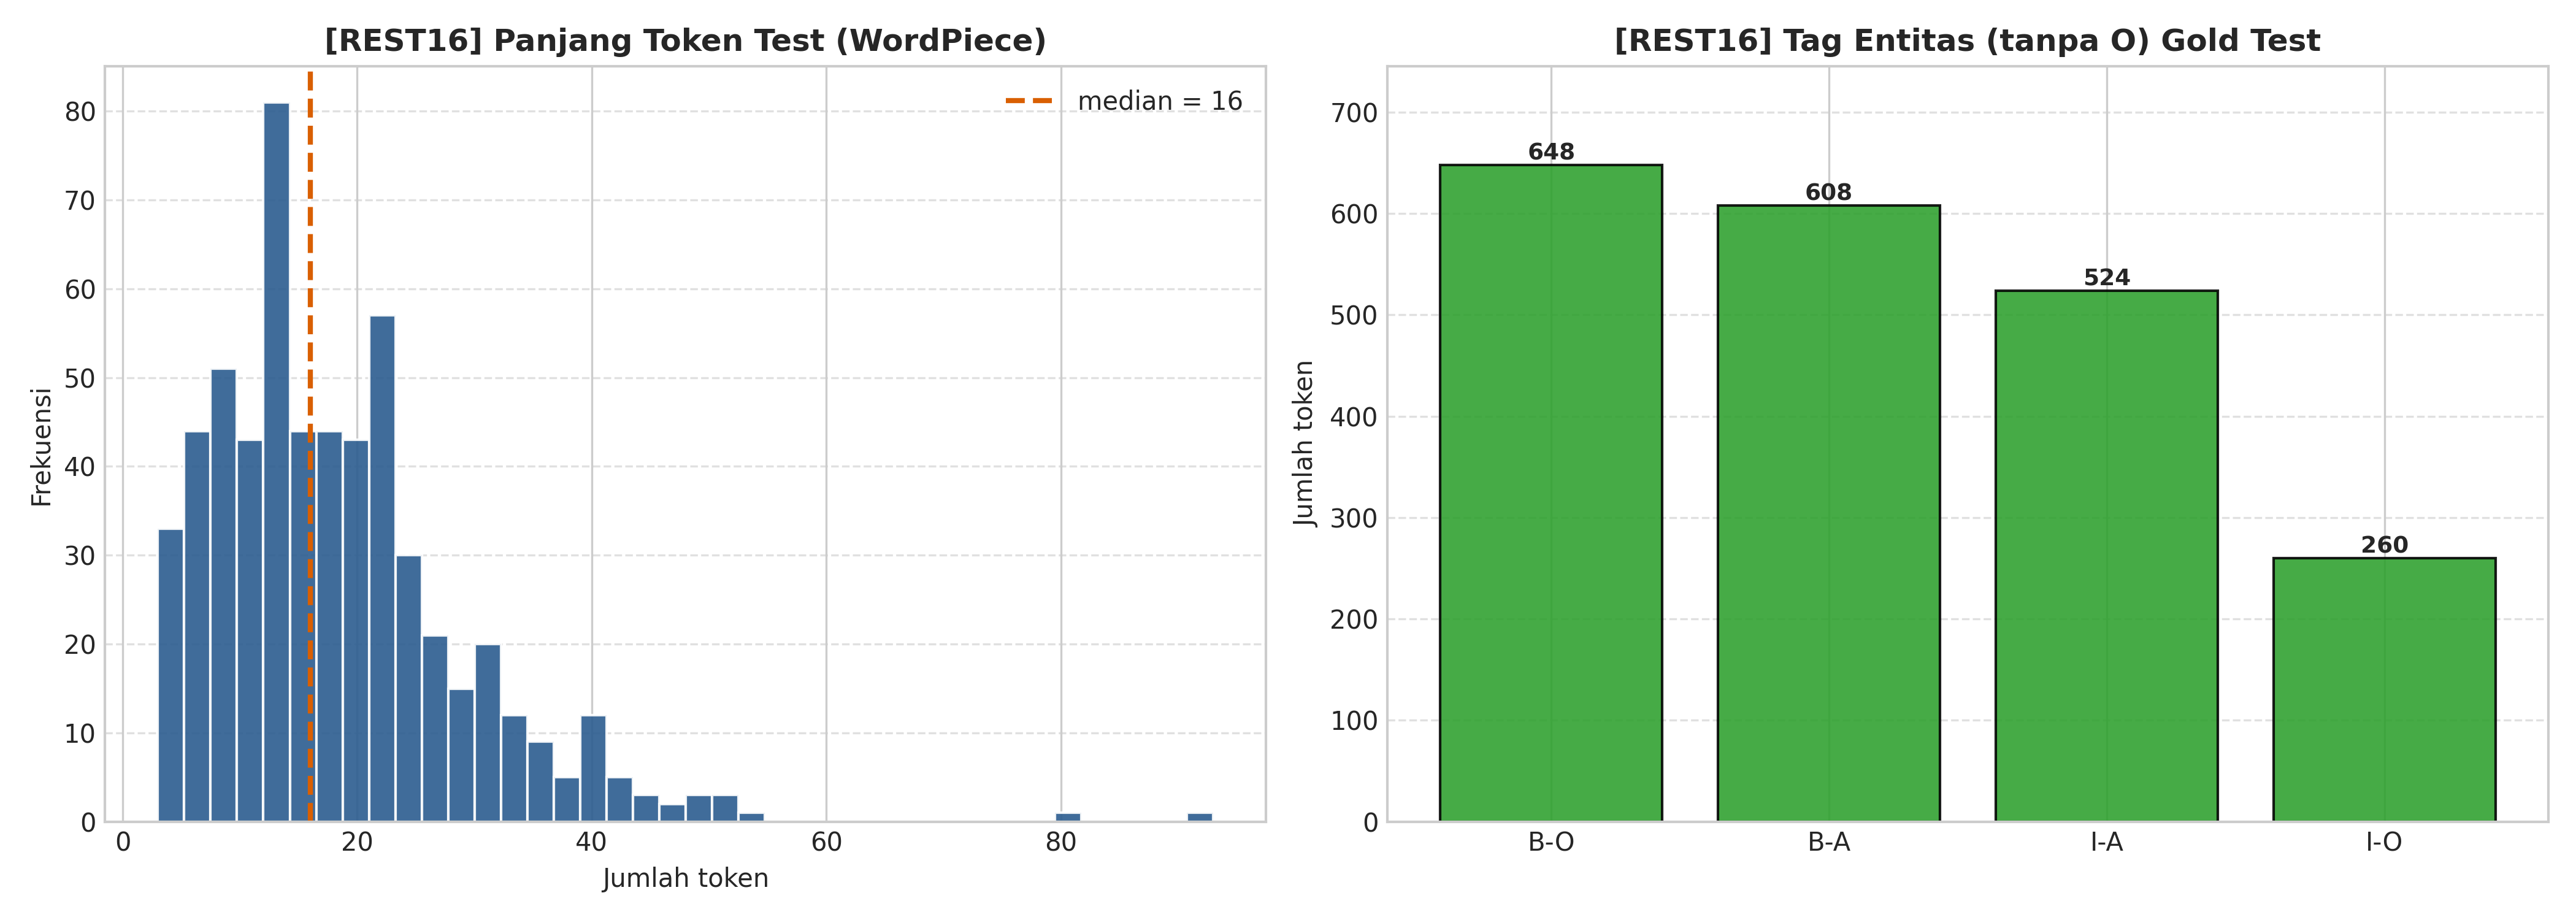

[plot] Kurva loss training & metrik validasi


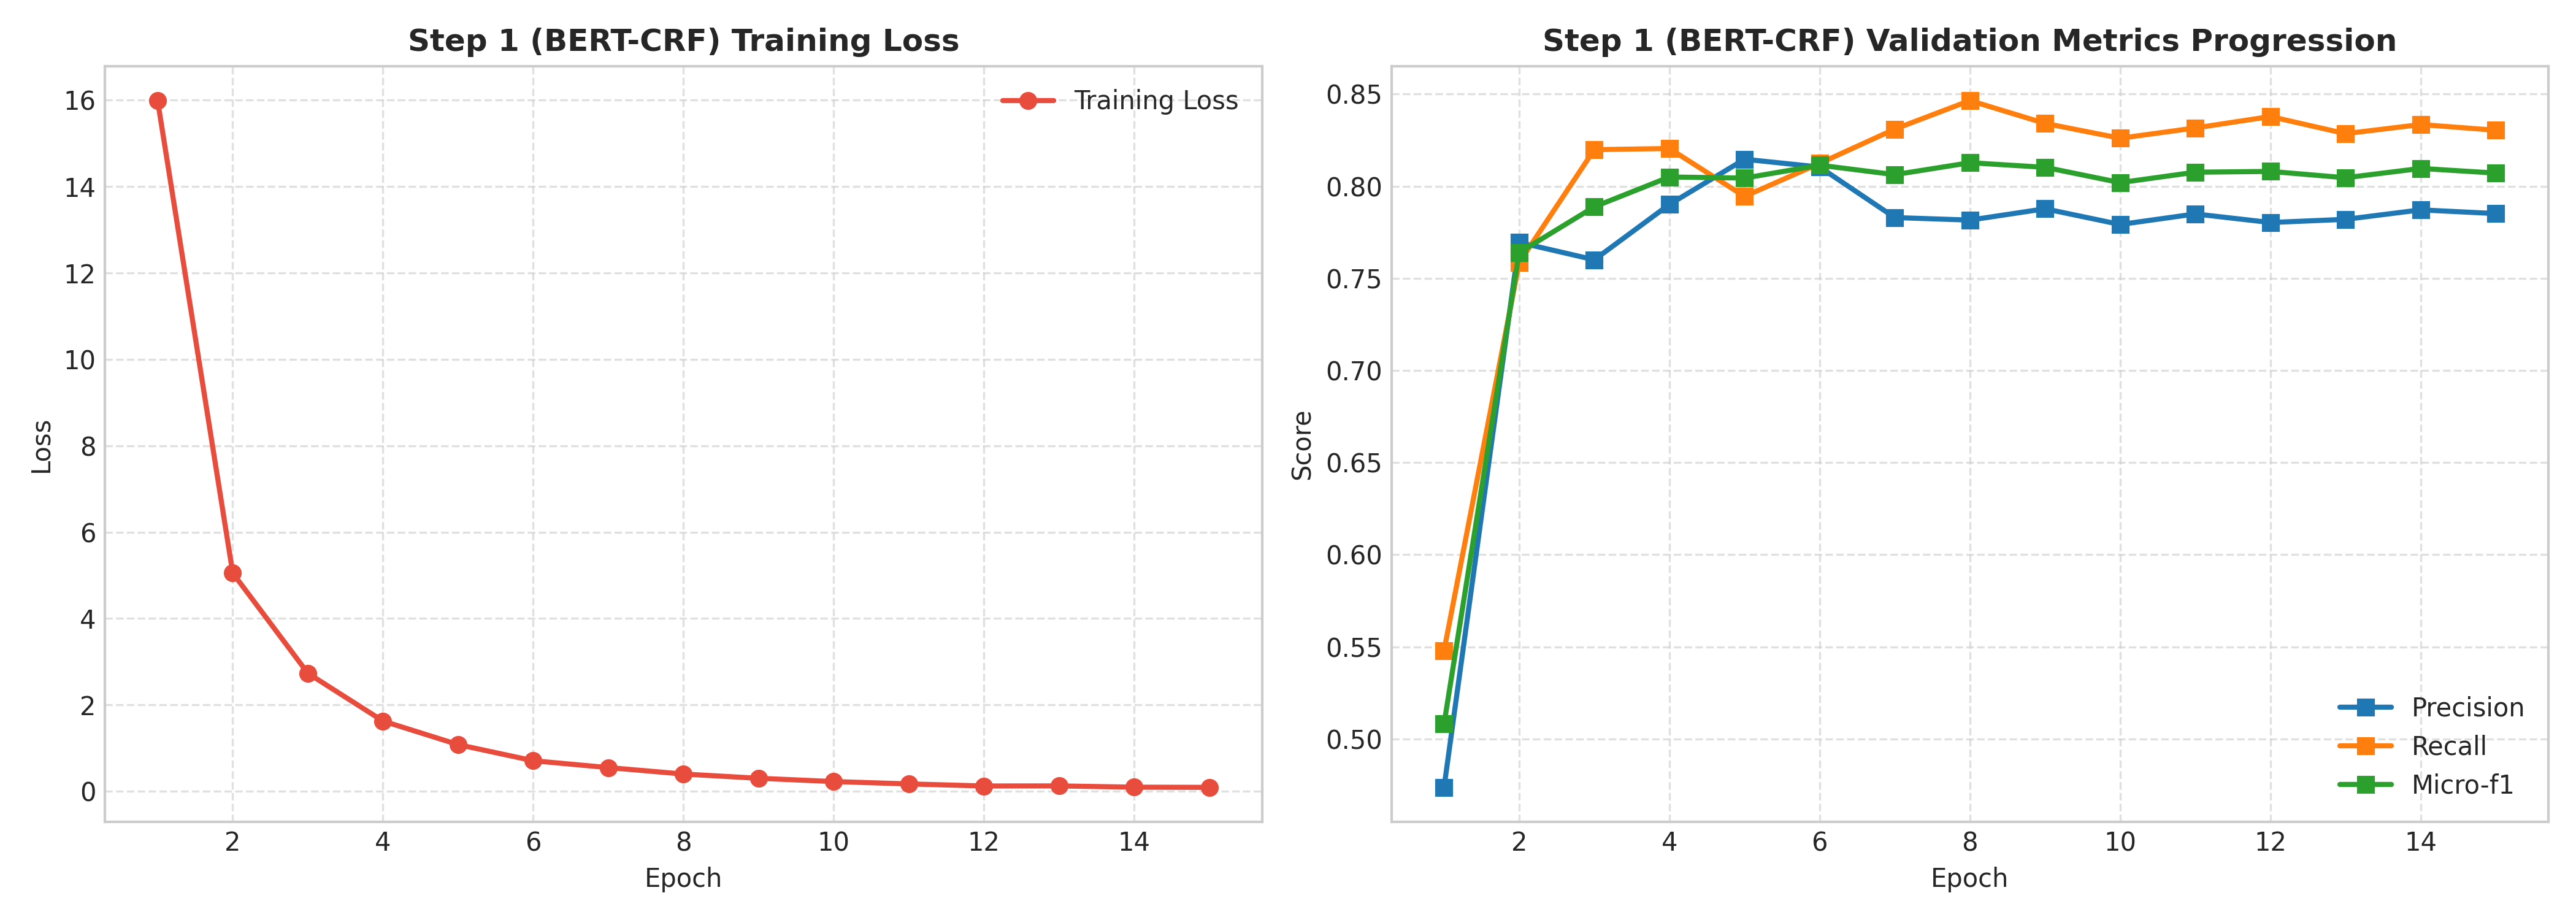

[plot] Distribusi aspect/opinion terprediksi


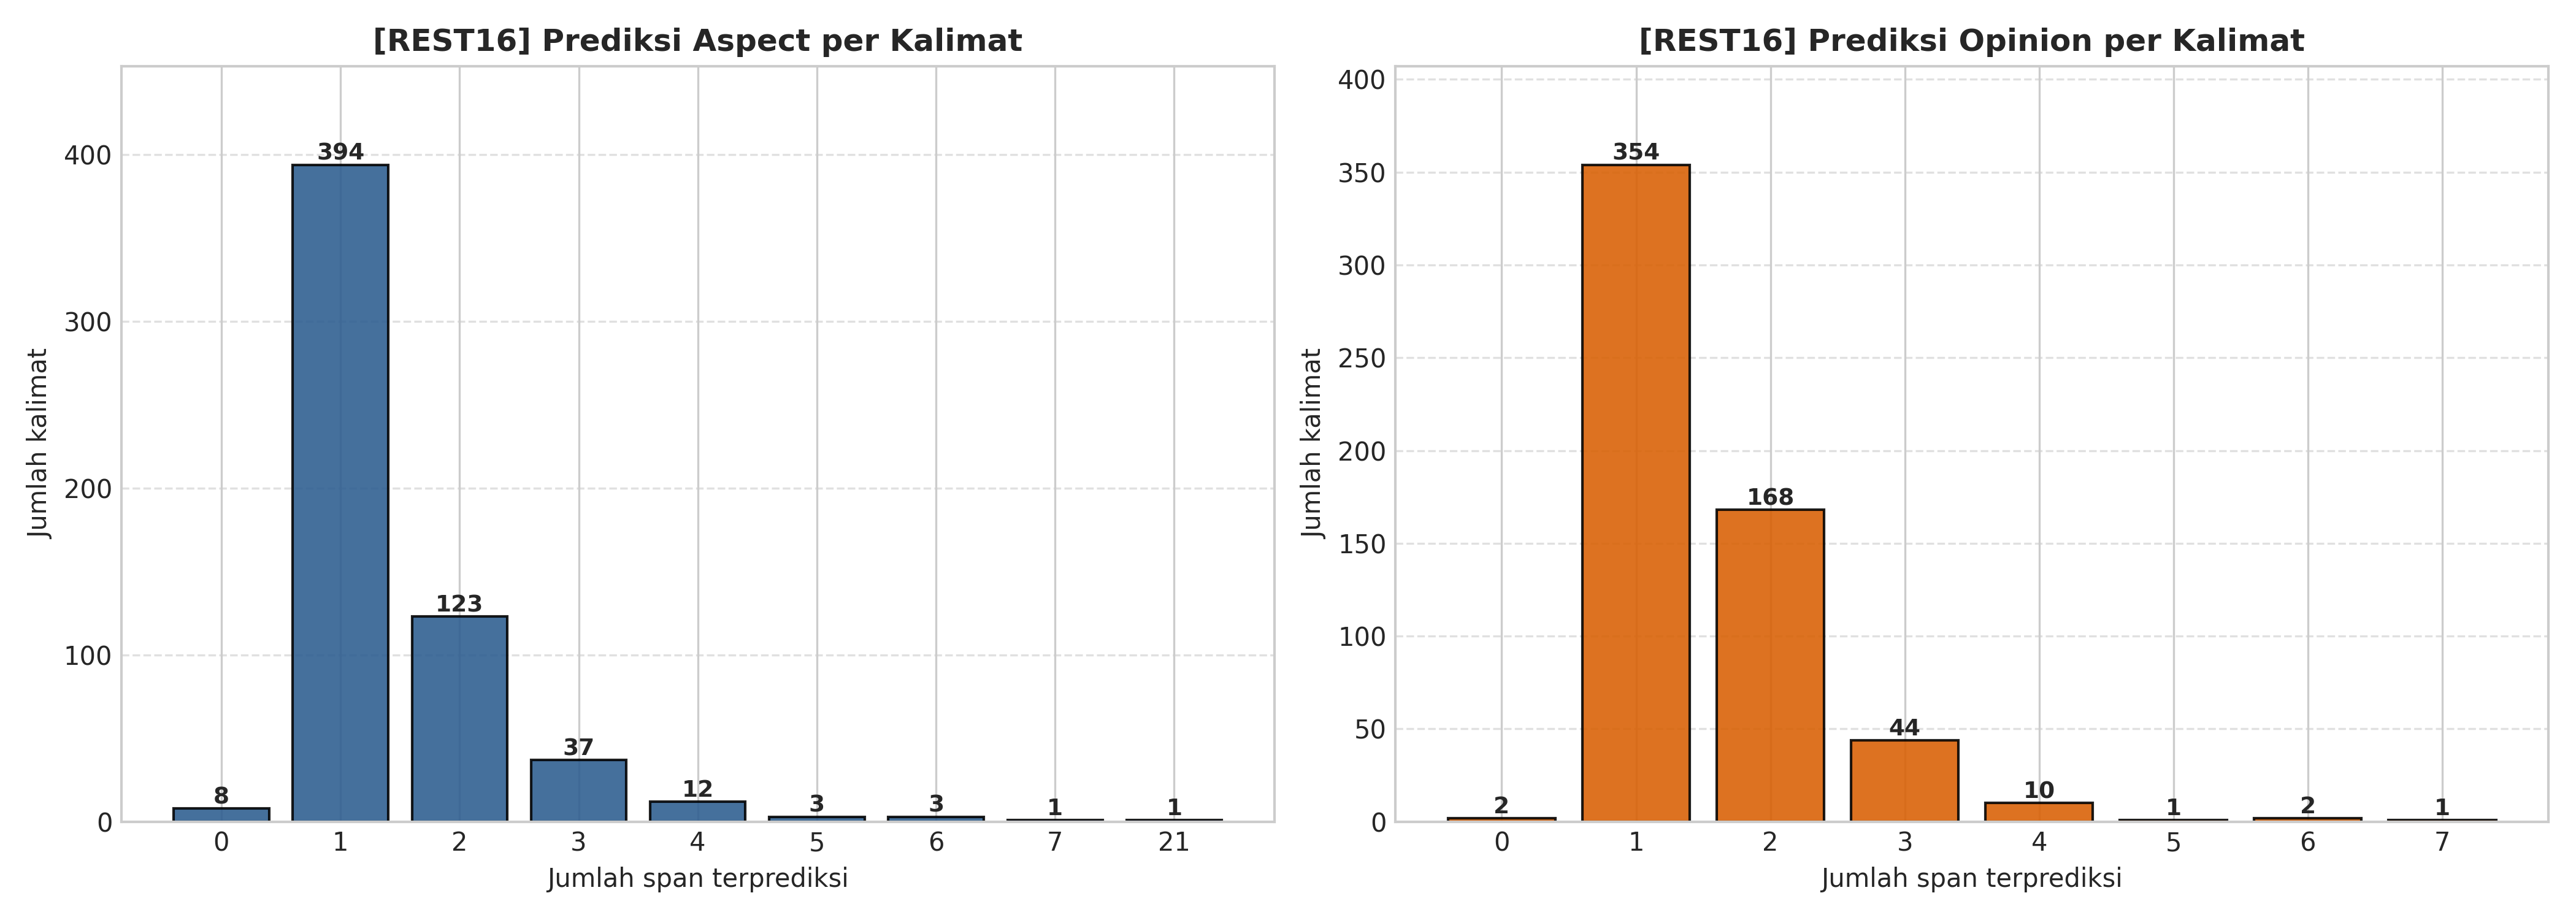

[markdown] Laporan disimpan: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/02_step1_ekstraksi.md

Laporan Markdown step 1: /content/drive/MyDrive/ACOS/results/rest16_31082026_144800/md/02_step1_ekstraksi.md
Lanjut ke '03_ACOS_Step1_to_Step2_Pair_Generation.ipynb'.


In [9]:
from IPython.display import Image, display

step1_plots = [
    ("02a_step1_data_profile.png", "Profil data: panjang token & distribusi tag"),
    ("03_step1_training_loss_f1_curve.png", "Kurva loss training & metrik validasi"),
    ("03b_step1_prediksi_distribusi.png", "Distribusi aspect/opinion terprediksi"),
]

rep.section("7. Visualisasi step 1")
for fname, caption in step1_plots:
    path = os.path.join(plots_dir, fname)
    if os.path.exists(path):
        print(f"[plot] {caption}")
        display(Image(path))
    else:
        print(f"[plot] Tidak ditemukan (dilewati): {fname}")

rep.text(f"Sesi: `{session_dirs['root']}`")
report_path = rep.save()

print(f"\nLaporan Markdown step 1: {report_path}")
print("Lanjut ke '03_ACOS_Step1_to_Step2_Pair_Generation.ipynb'.")
